import libraries

In [2]:
import pandas as pd
import numpy as np

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import GridSearchCV

import joblib


load final dataset.csv

In [3]:
df = pd.read_csv("../data/processed/dataset.csv")
df.head()


,match_id,batter,venue,batting_team,bowling_team,date,runs,recent_form,venue_avg,opponent_avg,career_avg,target_runs
0,548376,a ashish reddy,"rajiv gandhi international stadium, uppal",deccan chargers,royal challengers bangalore,2012-05-20,4,7.0,8.454545,11.0,7.000000,7.0
1,598000,a ashish reddy,"rajiv gandhi international stadium, uppal",sunrisers hyderabad,pune warriors,2013-04-05,7,6.4,8.454545,13.0,7.000000,14.0
2,598004,a ashish reddy,"rajiv gandhi international stadium, uppal",sunrisers hyderabad,royal challengers bangalore,2013-04-07,14,8.6,8.454545,11.0,8.000000,3.0
3,598048,a ashish reddy,m chinnaswamy stadium,sunrisers hyderabad,royal challengers bangalore,2013-04-09,3,7.6,17.500000,11.0,7.375000,16.0
4,598010,a ashish reddy,feroz shah kotla,sunrisers hyderabad,delhi daredevils,2013-04-12,16,8.8,16.000000,12.0,8.333333,4.0


FEATURES & TARGET

In [4]:
features = ['recent_form', 'venue_avg', 'opponent_avg', 'career_avg']
X = df[features]
y = df['target_runs']


In [5]:
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# Verify
print(df['date'].dtype)


datetime64[ns]


TIME-AWARE TRAIN-TEST SPLIT

In [6]:
split_date = df['date'].quantile(0.8)

X_train = X[df['date'] <= split_date]
X_test  = X[df['date'] > split_date]

y_train = y[df['date'] <= split_date]
y_test  = y[df['date'] > split_date]

print("Train:", X_train.shape)
print("Test :", X_test.shape)


Train: (11079, 4)
Test : (2736, 4)


In [7]:
df[['date']].head(3)


,date
0,2012-05-20
1,2013-04-05
2,2013-04-07


BASELINE MODEL recent form only

In [8]:
baseline_pred = X_test['recent_form']
baseline_actual = y_test

rmse_base = np.sqrt(mean_squared_error(baseline_actual, baseline_pred))
mae_base = mean_absolute_error(baseline_actual, baseline_pred)
r2_base = r2_score(baseline_actual, baseline_pred)

print("Baseline RMSE:", rmse_base)
print("Baseline MAE :", mae_base)
print("Baseline R2  :", r2_base)


Baseline RMSE: 23.392387675686095
Baseline MAE : 17.83654970760234
Baseline R2  : -0.032297016933233946


RANDOM FOREST MODEL

In [9]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)


RANDOM FOREST EVALUATION

In [10]:
rmse_rf = np.sqrt(mean_squared_error(y_test, rf_pred))
mae_rf = mean_absolute_error(y_test, rf_pred)
r2_rf = r2_score(y_test, rf_pred)

print("RF RMSE:", rmse_rf)
print("RF MAE :", mae_rf)
print("RF R2  :", r2_rf)


RF RMSE: 21.837023643164734
RF MAE : 16.542906883353474
RF R2  : 0.1004144818085736


XGBOOST (MAIN MODEL)

In [11]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)


XGBOOST EVALUATION

In [12]:
rmse_xgb = np.sqrt(mean_squared_error(y_test, xgb_pred))
mae_xgb = mean_absolute_error(y_test, xgb_pred)
r2_xgb = r2_score(y_test, xgb_pred)

print("XGB RMSE:", rmse_xgb)
print("XGB MAE :", mae_xgb)
print("XGB R2  :", r2_xgb)


XGB RMSE: 21.99857322521144
XGB MAE : 16.58191826076884
XGB R2  : 0.08705503946867432


In [13]:
from lightgbm import LGBMRegressor

lgbm = LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

lgbm.fit(X_train, y_train)

lgbm_pred = lgbm.predict(X_test)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000205 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1020
[LightGBM] [Info] Number of data points in the train set: 11079, number of used features: 4
[LightGBM] [Info] Start training from score 20.977254


LGBM evaluation

In [14]:
rmse_lgbm = np.sqrt(mean_squared_error(y_test, lgbm_pred))
mae_lgbm = mean_absolute_error(y_test, lgbm_pred)
r2_lgbm = r2_score(y_test, lgbm_pred)

print("LGBM RMSE:", rmse_lgbm)
print("LGBM MAE :", mae_lgbm)
print("LGBM R2  :", r2_lgbm)


LGBM RMSE: 22.05867706927033
LGBM MAE : 16.56320431581862
LGBM R2  : 0.08205958270722002


HYPERPARAMETER TUNING

In [17]:
param_grid = {
    'max_depth': [4, 6, 8],
    'learning_rate': [0.03, 0.05],
    'n_estimators': [200, 300]
}

grid = GridSearchCV(
    XGBRegressor(random_state=42),
    param_grid,
    scoring='neg_root_mean_squared_error',
    cv=3
)

grid.fit(X_train, y_train)

best_xgb = grid.best_estimator_


In [18]:
best_pred = best_xgb.predict(X_test)

rmse_best = np.sqrt(mean_squared_error(y_test, best_pred))
mae_best = mean_absolute_error(y_test, best_pred)
r2_best = r2_score(y_test, best_pred)

print("Tuned XGB RMSE:", rmse_best)
print("Tuned XGB MAE :", mae_best)
print("Tuned XGB R2  :", r2_best)


Tuned XGB RMSE: 21.784218087534494
Tuned XGB MAE : 16.420203917904903
Tuned XGB R2  : 0.10475991630419157


MODEL COMPARISON TABLE (REPORT GOLD)

In [16]:
results = pd.DataFrame({
    "Model": ["Baseline", "Random Forest", "XGBoost", "LightGBM", "Tuned XGBoost"],
    "RMSE": [rmse_base, rmse_rf, rmse_xgb, rmse_lgbm, rmse_best],
    "MAE":  [mae_base, mae_rf, mae_xgb, mae_lgbm, mae_best],
    "R2":   [r2_base, r2_rf, r2_xgb, r2_lgbm, r2_best]
})

results


,Model,RMSE,MAE,R2
0,Baseline,23.392388,17.836550,-0.032297
1,Random Forest,21.837024,16.542907,0.100414
2,XGBoost,21.998573,16.581918,0.087055
3,LightGBM,22.058677,16.563204,0.082060
4,Tuned XGBoost,21.784218,16.420204,0.104760


SHAP FEATURE IMPORTANCE

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


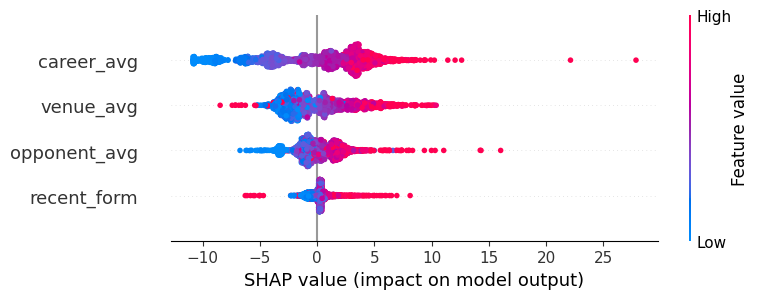

In [20]:
import shap

explainer = shap.Explainer(best_xgb)
shap_values = explainer(X_test)

shap.summary_plot(shap_values, X_test)


SAVE FINAL MODEL

In [22]:
joblib.dump(best_xgb, "../models/xgb_model.joblib")
print(" Final tuned XGBoost model saved")


 Final tuned XGBoost model saved
